In [2]:
from utils import * 
import subprocess
from files.bam import BamFile 
import copy
%load_ext autoreload 
%autoreload 2

# reverse_complement_genome_ids = ['bz_0', 'bz_1', 'bz_4', 'bz_5', 'bz_7', 'bz_8','bz_12']

In [13]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]
conserved_cluster_ids = level_1_conserved_cluster_ids + level_2_conserved_cluster_ids + level_3_conserved_cluster_ids

In [3]:
# It seems important to assess whether or not genes are contained on the same mRNA fragment, which we should be able to piece together from the metatranscriptomic data. 

sample_metadata_df = pd.read_csv('../data/sr-vp/sample_metadata.csv')
sample_metadata_df = sample_metadata_df[sample_metadata_df.regime == 'MetaT'].copy()

BOWTIE_CMD = 'bowtie2 -x {index_path} -1 {forward_reads_path} -2 {reverse_reads_path} -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > {output_path}'
BOWTIE_REF_PATH = '/home/philippar/bz_0.fasta'
BOWTIE_REF_NAME = os.path.basename(BOWTIE_REF_PATH).replace('.fna', '')
BOWTIE_INDEX_PATH = os.path.join('/home/philippar/bowtie/index/', BOWTIE_REF_NAME)

print(f'bowtie2-build {BOWTIE_REF_PATH} {BOWTIE_INDEX_PATH}') # Only need to build the index once for a given reference. 

for row in sample_metadata_df.itertuples():
    output_path = os.path.join('/home/philippar/bowtie/', f'{row.sample_id}.bam')
    # bowtie2 mapping command for running on biotite. 
    cmd = BOWTIE_CMD.format(index_path=BOWTIE_INDEX_PATH, forward_reads_path=row.forward_reads_path, reverse_reads_path=row.reverse_reads_path, output_path=output_path)
    print(f'sbatch --wrap "{cmd}"')

bowtie2-build /home/philippar/bz_0.fasta /home/philippar/bowtie/index/bz_0.fasta
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/bz_0.fasta -1 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_06_2024_metaT/raw.d/SR-VP_Bioreactor_ck_bot_05_06_2024_metaT_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_06_2024_metaT/raw.d/SR-VP_Bioreactor_ck_bot_05_06_2024_metaT_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2024_metat.bam"
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/bz_0.fasta -1 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025_metaT/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_metaT_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025_metaT/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_metaT_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2

In [4]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['gene_id'] = genes_df.index
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id == 'bz_0'].copy()
genes_df['length'] = genes_df.seq.apply(len)
genes_df['gc_content'] = genes_df.nt_seq.apply(lambda seq : (seq.count('C') + seq.count('G')) / len(seq))

supported_gene_ids = np.loadtxt('analysis-1-cluster-supported_gene_ids.txt', dtype=str)
prodigal_gene_ids = genes_df[~genes_df.prodigal_gene_id.isnull()].gene_id.tolist()

genes_df = genes_df[genes_df.gene_id.isin(supported_gene_ids)].copy()

# genes_df[~genes_df.prodigal_gene_id.isnull()].sort_values('start')

for row in genes_df.itertuples():
    start, stop = row.start, row.stop
    genes_df.loc[row.Index, 'start'] = row.genome_size - (stop + 1)
    genes_df.loc[row.Index, 'stop'] = row.genome_size - (start + 1) 
    genes_df.loc[row.Index, 'strand'] = '+' if (row.strand == '-') else '-'

assert np.all((genes_df.stop - (genes_df.start - 1)) % 3 == 0), 'Some of the start and stop indices are incorrect.'

cluster_1_gene_id = genes_df[(genes_df.cluster_id == 1)].index[0]
cluster_3_gene_id = genes_df[(genes_df.cluster_id == 3) ].index[0]
cluster_25_gene_id = genes_df[(genes_df.cluster_id == 25)].index[0]
cluster_20_gene_id = genes_df[(genes_df.cluster_id == 20)].index[0]

GENOME_ID_TO_GENOME_MAP = {genome_id:FASTAFile.from_file(f'../data/genomes/{genome_id}.fasta').seqs[0] for genome_id in genes_df.genome_id.unique()}

In [ ]:
paths = glob.glob('../data/genes/bowtie/*bam')
for path in paths:
    # Need an index file in order to read mappings to a specified ref_id.
    if not os.path.exists(path + '.bai'):
        subprocess.run(f'samtools index {path}', shell=True, check=True)

metat_df = pd.concat([BamFile.from_file(path).to_df() for path in paths])

In [6]:
# bed_path = 'analysis-1-metat-bz_0_genes.bed'
# bam_path = '../data/genes/bowtie/ch4_bottom_2025_metat.bam'

# cols = ['genome_id', 'start', 'stop', 'gene_id', 'score', 'strand']
# df = genes_df.copy()
# df['start'] = df.start - 1 # Switch to 0-indexed for BED.
# df['score'] = '.'
# df = df.loc[prodigal_gene_ids, cols].copy()
# df.to_csv(bed_path, header=False, index=False, sep='\t')

# print('Number of genes on the + strand:', (df.strand == '+').sum())
# print('Number of genes on the - strand:', (df.strand == '-').sum())

# cmd = f'infer_experiment.py -r {bed_path} -i {bam_path}'
# result = subprocess.run(cmd, shell=True, check=True, capture_output=True)
# print(result.stdout.decode())

# # The first symbol is the read's mapping orientation; the second symbol is the gene's strand
# # Most mate 1 reads map to the + reference strand with the gene in the - orientation, or, likewise, the mate 1 
# # read maps to the - reference strand for a gene in the + orientation. 

# # So this means that for a gene on the + strand, I should pay attention to read pairs where mate 1 aligns in the reverse
# # orientation and mate 2 aligns in the forward orientation.

In [7]:
# The mapping of ORFs in Geneious looks odd; specifically, for both the cluster_20 and cluster_25 ORFs, coverage seems to be substantially higher
# over the N-terminus. I first want to see if this pattern persists when looking only at reads which map to the ORF in the correct orientation
# (i.e. would be produced by he gene being transcribed).

# After filtering the BAM file, it seems as though the odd transcriptional pattern persists.

def gff_file_from_df(df:pd.DataFrame, tool:str='Prodigal-OrfM', path:str='analysis-1-metat-bz_0.gff'):

    for col in ['genome_id', 'start', 'stop', 'strand', 'gene_id']:
        assert col in df.columns, f'gff_file_from_df: DataFrame is missing column {col}.'

    df = df[['genome_id', 'start', 'stop', 'strand', 'gene_id']].copy()
    df['gene_id'] = df.gene_id.apply(lambda gene_id : f'ID={gene_id}') # Needs to be in this format for featureCounts.
    df['tool'], df['frame'], df['score'], df['feature'] = tool, 0, '.', 'CDS'
    
    # Make sure these are in the right order... 
    fields = ['genome_id', 'tool', 'feature', 'start', 'stop',  'score', 'strand', 'frame', 'gene_id']
    df = df[fields].copy()
    df.to_csv(path, header=False, index=False, sep='\t')
    return path 


def run_feature_counts(name:str, bam_path:str, gff_path:str, output_dir:str='../data/genes/feature_counts', s:int=2):
    '''
    :param s: The strandedness of the library. 
    '''
    bam_file_name = os.path.basename(bam_path)

    output_paths = dict()
    output_paths['counts'] = os.path.join(output_dir, name)
    output_paths['summary'] = output_paths['counts'] + '.summary'
    output_paths['mapping'] = os.path.join(output_dir, bam_file_name + '.featureCounts.bam')
    # output_paths['index'] = bam_path + '.featureCounts.bam.bai'

    output_path = output_paths['counts']
    cmd = f'featureCounts -p -s {s} -g ID -t CDS -a {gff_path} -o {output_path} -R BAM {bam_path}' # Map reads, but being aware of the strand.
    print('run_feature_counts:', cmd)
    subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    for name, path in output_paths.items():
        assert os.path.exists(path), f'run_feature_counts: Output path {path} is missing.'

    subprocess.run(['mv', output_paths['mapping'], output_paths['mapping'].replace('.featureCounts.bam', '')], check=True)
    output_paths['mapping'] = output_paths['mapping'].replace('.featureCounts.bam', '')

    # output_path = os.path.abspath(output_paths['mapping']) # Generate an index file. 
    output_path =output_paths['mapping'] # Generate an index file. 
    cmd = f'samtools index {output_path}'
    print('run_feature_counts:', cmd)
    subprocess.run(cmd, shell=True, check=True)
    return output_paths
        

In [8]:
sample_id = 'ch4_bottom_2025_metat'
bam_path = f'../data/genes/bowtie/{sample_id}.bam'
gff_path = gff_file_from_df(genes_df.assign(gene_id=genes_df.index))

output_paths = run_feature_counts(sample_id, bam_path, gff_path)


run_feature_counts: featureCounts -p -s 2 -g ID -t CDS -a analysis-1-metat-bz_0.gff -o ../data/genes/feature_counts/ch4_bottom_2025_metat -R BAM ../data/genes/bowtie/ch4_bottom_2025_metat.bam
run_feature_counts: samtools index ../data/genes/feature_counts/ch4_bottom_2025_metat.bam


In [ ]:
def filter_bam(path, overwrite=True):
    '''Filter a BAM file to include only reads which are assigned a feature by featureCounts.
    
    :param path: The path to the unfiltered BAM file. 
    :param overwrite: Whether or not to overwrite an existing output file.
    '''
    output_file_name = os.path.basename(path).replace('.bam', '_filtered.bam')
    output_path = os.path.join(os.path.dirname(path), output_file_name)
    if (not os.path.exists(output_path)) or overwrite:
        try:
            # cmd = f'bamtools filter -tag \"XS:Assigned\" -in {path} -out {output_path}'
            cmd = f'samtools view -e \'[XS] == "Assigned"\' {path} -o {output_path}' # Why use this tag syntax?
            print('filter_bam:', cmd)
            subprocess.run(cmd, shell=True, check=True)
        except:
            return None
    return output_path 

bam_path = filter_bam(output_paths['mapping'])

filter_bam: samtools view -e '[XS] == "Assigned"' ../data/genes/feature_counts/ch4_bottom_2025_metat.bam -o ../data/genes/feature_counts/ch4_bottom_2025_metat_filtered.bam


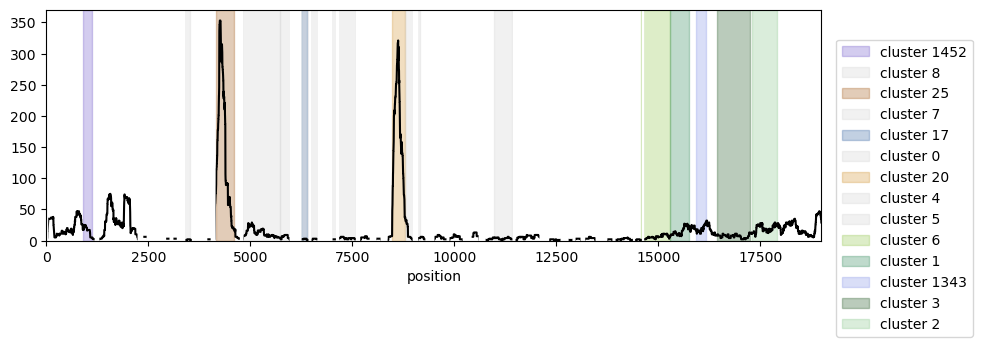

In [14]:
# Want to look at the coverage profile of the transcripts. 

def plot_mapping(figure_df, func=np.sum, metric:str='mapped', ax=None, label=None, max_nm=10, read_length=150):
    '''Plot the coverage of a reference sequence by mapped reads in a BAM file.'''

    figure_df['mapped'] = (~figure_df.unmapped).astype(int)
    figure_df = figure_df[figure_df.NM <= max_nm].copy()

    ref_length = figure_df.ref_length.iloc[0]
    positions = np.arange(ref_length)
    values = np.zeros((len(figure_df), len(positions)))

    for i, row in enumerate(figure_df.itertuples()):
        start = row.position
        stop = min(start + 150, ref_length)
        values[i, start:stop] = getattr(row, metric)

    values = func(values, axis=0)
    values = np.where(values == 0, np.nan, values) # Set the value to NaN where there is no coverage so it is clearer on the graph. 
    ax.plot(positions, values, label=label, color='black')
    ax.set_xlabel('position')

    stats = dict()
    stats['coverage'] = (read_length * len(figure_df)) / ref_length
    stats['variance'] = np.var(values)
    stats['coefficient_of_variance'] = np.sqrt(stats['variance']) / stats['coverage']
    stats['read_count'] = figure_df.mapped.sum()
    stats['fraction_covered'] = ((values > 0) & (~np.isnan(values))).mean()

    for i in np.where(np.isnan(values))[0]:
        ax.axvline(i, color='white')
        
    return stats, values


paths = glob.glob('../data/genes/bowtie/*bam')
for path in paths:
    # Need an index file in order to read mappings to a specified ref_id.
    if not os.path.exists(path + '.bai'):
        subprocess.run(f'samtools index {path}', shell=True, check=True)

# ch4_bottom_2025 is best. Spike in clusters 20 and 25 is evident in all samples. 
# figure_df = pd.concat([BamFile.from_file(path).to_df() for path in paths if ('no3_top_2025' in path)])
figure_df = pd.concat([BamFile.from_file(path).to_df() for path in paths if ('ch4_bottom_2025' in path)])
# figure_df = pd.concat([BamFile.from_file(path).to_df() for path in paths])

x_min = 0
x_max = 19000


palette = dict()
palette = {cluster_id:'lightgray' for cluster_id in genes_df.cluster_id.unique()}
# palette.update({cluster_id:'gray' for cluster_id in level_2_conserved_cluster_ids})
# palette.update({cluster_id:'black' for cluster_id in level_1_conserved_cluster_ids})
# palette.update({cluster_id:'gray' for cluster_id in level_3_conserved_cluster_ids})
palette.update({1:"#2B8756", 3:"#1C531E", 2:"#86C589", 6:"#91C449", 20:"#D19431", 25:"#A25716"})
palette.update({1343:"#8492E7", 1452:"#6F56CA", 17:"#3665A2"})

fig, ax = plt.subplots(figsize=(10, 3))
stats, values = plot_mapping(figure_df, ax=ax)

for row in genes_df.itertuples():
    if row.cluster_id in level_1_conserved_cluster_ids + [20, 25, 1452, 1343, 17]:
        ax.axvspan(row.start, row.stop, alpha=0.3, color=palette[int(row.cluster_id)], label=f'cluster {int(row.cluster_id)}')

ax.legend(loc='upper left', bbox_to_anchor=(1.01, 0.9))
ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylim(ymin=0)

# cluster_20
# ax.axvline(8486, ls='--', color='black', lw=0.7)
# ax.axvline(8784, ls='--', color='black', lw=0.7)

# cluster_25 4157-4596
# ax.axvline(4157, ls='--', color='black', lw=0.7)
# ax.axvline(4596, ls='--', color='black', lw=0.7)

plt.show()
    

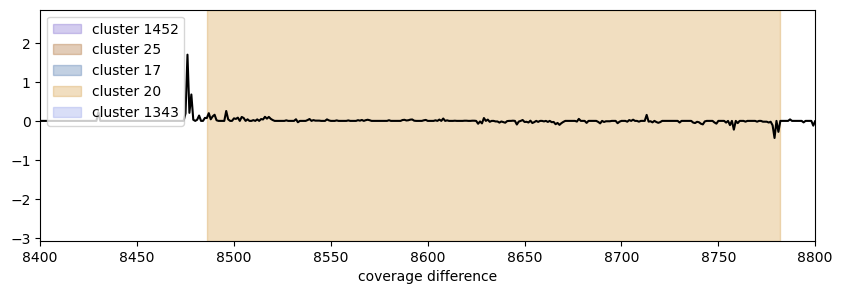

In [ ]:
start, stop = 4100, 4700
start, stop = 8400, 8800

fig, ax = plt.subplots(figsize=(10, 3))

# values = np.where(np.isnan(values), 0, values)
values = np.where(np.isnan(values) | (values == 0), 1, values) # Use a pseudocount. 
# diffs = np.abs(np.diff(values))
# Want to get the differences as fold-changes, which means dividing by the leftmost of two adjacent values.
diffs = np.log2(values[1:] / values[:-1])

ax.plot(np.arange(len(diffs)), diffs, color='black')
ax.set_xlim(xmin=start, xmax=stop)

for row in genes_df.itertuples():
    if row.cluster_id in [20, 25, 1452, 1343, 17]:
        ax.axvspan(row.start, row.stop, alpha=0.3, color=palette[int(row.cluster_id)], label=f'cluster {int(row.cluster_id)}')

ax.legend(loc='upper left')
ax.set_xlabel('position')
ax.set_xlabel('coverage difference')
# ax.set_ylim(ymax=1)
plt.show()


plot_gc_content: Plotting GC content for a sequence of length 19040


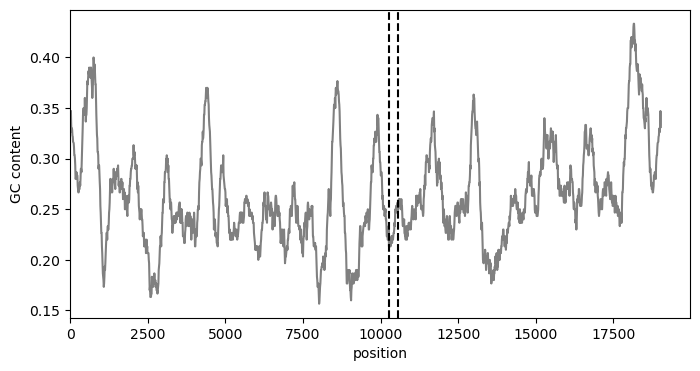

In [ ]:
genome_id = 'bz_0'

def plot_gc_content(seq, window_size:int=300, step_size:int=10, x_min:int=0, x_max:int=None, ax:plt.Axes=None):
    '''
    
    '''
    print(f'plot_gc_content: Plotting GC content for a sequence of length {len(seq)}')

    x = list(range(0, len(seq), step_size))
    windows = [seq[max(0, i - window_size//2):i + window_size//2] for i in x]
    y = np.array([get_gc_content(window) for window in windows]).ravel()

    ax.plot(x, y, color='gray')
    ax.set_ylabel('GC content')
    ax.set_xlabel('position')
    ax.set_xlim(xmin=x_min, xmax=x_max)

supported_gene_ids = np.loadtxt('analysis-1-cluster-supported_gene_ids.txt', dtype=str) 

figure_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
figure_df['cluster_id'] = figure_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
figure_df = figure_df[figure_df.genome_id == 'bz_0'].copy()
figure_df['gc_content'] = figure_df.nt_seq.apply(get_gc_content)
figure_df = figure_df[figure_df.index.isin(supported_gene_ids)].copy()

fig, ax = plt.subplots(figsize=(8, 4))

bz_0_cluster_20_start = len(GENOME_ID_TO_GENOME_MAP['bz_0']) - genes_df.loc['orfm.bz_0.1_114'].stop + 1
bz_0_cluster_20_stop = len(GENOME_ID_TO_GENOME_MAP['bz_0']) - genes_df.loc['orfm.bz_0.1_114'].start + 1

plot_gc_content(GENOME_ID_TO_GENOME_MAP['bz_0'], ax=ax)
ax.axvline(bz_0_cluster_20_start, ls='--', color='black')
ax.axvline(bz_0_cluster_20_stop, ls='--', color='black')

In [ ]:
# tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
# genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())

# tmhmm_df = tmhmm_file.to_df()
# tmhmm_df = tmhmm_df[tmhmm_df.gene_id.isin(genes_df.index)].copy()
# tmhmm_df = tmhmm_df[tmhmm_df.location == 'TMhelix'].copy()

# # Load annotations for gene IDs in genes_df.
# INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
# annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
# annot_df = annot_df[annot_df.gene_id.isin(genes_df.index)].copy()
# # annot_df

In [ ]:
# # cluster_25
# cluster_25_gene_id = genes_df[(genes_df.cluster_id == 25)].index[0]
# print('cluster_25 gene ID:', cluster_25_gene_id)
# print(f'cluster_25 num. TMHs:', genes_df.loc[cluster_25_gene_id].num_tmhs)
# print(f'cluster_25 annotations:', ', '.join(annot_df[annot_df.gene_id == cluster_25_gene_id].signature_description.unique()))

In [ ]:
# foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*')])
# foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin([cluster_20_gene_id])]

In [ ]:
# filters = dict()
# filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
# filters['short_alignment'] = foldseek_search_df.alignment_length < 50

# foldseek_search_df = apply_filters(filters, foldseek_search_df)
# foldseek_search_df.sort_values('probability', ascending=False)[['target_header', 'alignment_tm_score', 'alignment_length', 'query_length', 'target_length']]
# foldseek_search_df.sort_values('probability', ascending=False)[['target_header', 'alignment_tm_score', 'alignment_length', 'query_length', 'target_length']].target_header.tolist()

In [ ]:
# # cluster_20

# cluster_20_gene_id = genes_df[(genes_df.cluster_id == 20)].index[0]
# print('cluster_20 gene ID:', cluster_20_gene_id)
# print(f'cluster_20 num. TMHs:', genes_df.loc[cluster_20_gene_id].num_tmhs)
# print(f'cluster_20 annotations:', ', '.join(annot_df[annot_df.gene_id == cluster_20_gene_id].signature_description.unique()))
# print(genes_df.loc[cluster_20_gene_id].seq, end='\n\n')

# # Prokaryotic membrane lipoprotein lipid attachment site profile is from residues 1-30 (the extreme N terminus), which makes sense. 
# # In theory, these proteins are cleaved (lipobox recognition) at a conserved cysteine residue by host machinery, and then a lipid is added which
# # anchors the protein in a membrane. However, I am a bit skeptical because these seem to mostly be in bacteria, and it seems unusual to have this
# # in addition to two other membrane proteins.

# # If this is a genuine lipobox, then the protein would be excreted, and the N-terminus would be extracellular. In that case, the positively-charged 
# # C terminus is outside the cell, which is unusual. Even if the lipobox annotation is wrong, TMHMM predicts the N terminus is inside, which would
# # still put the C terminus outside. 

# # https://www.nature.com/articles/nsmb1057

# # Basically the entire protein is transmembrane helices (except perhaps the terminal ~15 residues). There is a group of three helices. 
# # It also doesn't seem to interact with any other proteins, or oligomerize. 

# foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*')])
# foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin([cluster_20_gene_id])].copy()

# filters = dict()
# filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.6
# filters['short_alignment'] = foldseek_search_df.alignment_length < 50
# foldseek_search_df = apply_filters(filters, foldseek_search_df)

# target_header_map = dict()
# target_header_map['A0A6J5PKW0'] = 'internal virion protein B'
# target_header_map['A0A0U4JLP2'] = 'Acb2/Tad1 hairpin domain-containing protein' # This is not a membrane protein
# target_header_map['A0A8S5Q4N3'] = 'Acb2/Tad1 hairpin domain-containing protein' # This is not a membrane protein
# target_header_map['B2BTN4'] = 'Acb2/Tad1 hairpin domain-containing protein' # This is not a membrane protein
# target_header_map['A0A249XSR1'] = 'Acb2/Tad1 hairpin domain-containing protein' # This is not a membrane protein
# target_header_map['W8NWL0'] = 'Acb2/Tad1 hairpin domain-containing protein' # This is not a membrane protein
# target_header_map['A0A8S5NKU4'] = 'Acb2/Tad1 hairpin domain-containing protein' # This is not a membrane protein
# target_header_map['A0A1B1IRT2'] = 'Not named' 
# target_header_map['A0A8S5QQG9'] = 'Not named' 
# target_header_map['A0A8S5MUL3'] = 'Not named' 
# target_header_map['A0A8T8L7G1'] = 'Not named' 
# target_header_map['A0A2H4X2G4'] = 'Not named' 


In [ ]:
# categories = dict()
# categories['transmembrane protein'] = foldseek_search_df.target_header.str.contains('transmembrane protein', case=False)
# categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized|not named', case=False)
# categories['MFS'] = foldseek_search_df.target_header.str.contains('MFS')
# categories['UPF0358'] = foldseek_search_df.target_header.str.contains('UPF0358') # UPF0358 looks similar! But not membrane-related, https://www.ebi.ac.uk/interpro/entry/InterPro/IPR009983/
# categories['DNA-directed RNA polymerase subunit beta'] = foldseek_search_df.target_header.str.contains('DNA-directed RNA polymerase|RNA polymerase', case=False) # False positive. 
# categories['ribosome recycling factor'] = foldseek_search_df.target_header.str.contains('ribosome recycling|ribosome-recycling', case=False) # False positive. 
# categories['cation diffusion facilitator family'] = foldseek_search_df.target_header.str.contains('cation diffusion|cation efflux|cation transporter', case=False) # Cation transporters have many more TMHs.
# categories['internal virion protein'] = foldseek_search_df.target_header.str.contains('7ey7|internal virion', case=False) # Cation transporters have many more TMHs.

# foldseek_search_df['category'] = np.select(*list(zip(*categories.items()))[::-1], default='none')

# foldseek_search_df[foldseek_search_df.category == 'none'].sort_values('alignment_tm_score', ascending=False).target_header.tolist()

In [ ]:
# # Note that most genes are in the + orientation. The one Prodigal-predicted gene in the - orientation is on the baby replichore at the end

# start, stop = 10000, 11000
# print(f'Conserved genes between positions {start} and {stop}:')
# for row in genes_df[(genes_df.start > start) & (genes_df.stop < stop)].itertuples():
#     # if row.cluster_id in conserved_cluster_ids:
#     if True:
#         info = [row.gene_id]
#         info += [f'cluster_{int(row.cluster_id)}']
#         info += [f'Prodigal-predicted? {not pd.isnull(row.prodigal_gene_id)}']
#         info += [f'strand {row.strand}']
#         info += [f'length {len(row.seq)} aa']
#         info += [f'{row.start}-{row.stop}']
#         print('\t' + '\t'.join(info))

In [ ]:
# # Can we manually check to see if there is an RNA molecule spanning the gene boundaries?
# # So would be looking for an mRNA whose position is to the left of min(cluster_a_stop, cluster_b_stop) and whose end point is
# # to the right of max(cluster_a_start, cluster_b_start)

# # Actually, this is not what I want, I want to look for a continuous stretch of mRNA connecting the region (no breaks). So 
# # honestly, the plot might be enough. 

# for row in genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].itertuples():
#     print(f'cluster {int(row.cluster_id)}: {row.start} - {row.stop}')

